<a href="https://colab.research.google.com/github/JaberAhmad555/Predictive-Maintenance-on-Industrial-Machine-Sensor-Data/blob/main/Predictive_Maintenance_on_Industrial_Machine_Sensor_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef,
    precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [ ]:
df = pd.read_csv("/content/predictive_maintenance.csv")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))


Shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure



Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isna().sum())

df = df.drop_duplicates()


Duplicate rows: 0

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


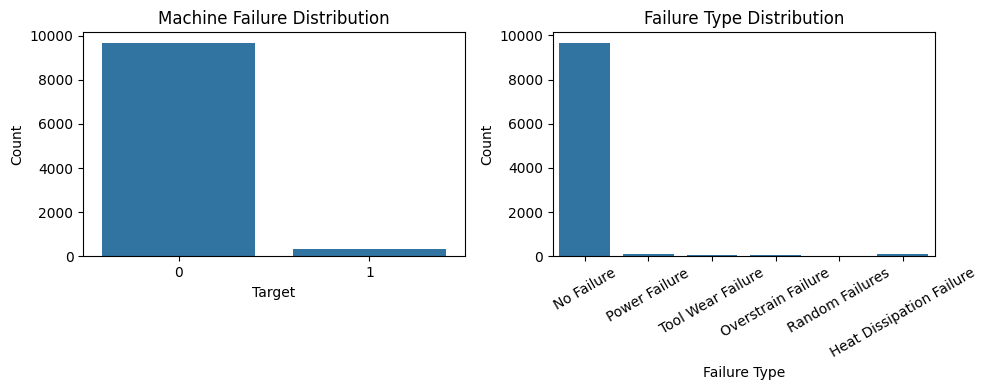

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=df["Target"])
plt.title("Machine Failure Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(x=df["Failure Type"])
plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


In [ ]:
TARGET_COL = "Target"
FAILTYPE_COL = "Failure Type"
ID_COLS = ["UDI", "Product ID"]

X = df.drop(columns=ID_COLS + [TARGET_COL, FAILTYPE_COL], errors="ignore")
y = df[TARGET_COL].astype(int)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())


Feature matrix shape: (10000, 6)
Target distribution:
Target
0    9661
1     339
Name: count, dtype: int64


In [ ]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)


Categorical columns: ['Type']
Numerical columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())


Training set shape: (8000, 6)
Test set shape: (2000, 6)

Training target distribution:
Target
0    7729
1     271
Name: count, dtype: int64

Test target distribution:
Target
0    1932
1      68
Name: count, dtype: int64


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight="balanced_subsample", random_state=42),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Neural Net (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=250, early_stopping=True, random_state=42)
}


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "bal_acc": "balanced_accuracy"
}

cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "Balanced Accuracy": scores["test_bal_acc"].mean()
    })

cv_results = pd.DataFrame(cv_results).sort_values("PR-AUC", ascending=False)
display(cv_results)


,Model,Accuracy,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
3,Histogram Gradient Boosting,0.984250,0.733718,0.969915,0.811663,0.821224
2,Random Forest,0.978125,0.547151,0.970322,0.751463,0.694976
1,SVM (RBF),0.919125,0.421030,0.960223,0.660681,0.893975
5,Neural Net (MLP),0.971875,0.372790,0.929711,0.517457,0.625920
4,KNN,0.970000,0.248391,0.892507,0.516518,0.573324
0,Logistic Regression,0.822500,0.234570,0.896525,0.440897,0.813789


In [ ]:
best_model_name = cv_results.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)

y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("Best model selected by CV PR-AUC:", best_model_name)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))
print("Test Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Test MCC:", matthews_corrcoef(y_test, y_pred))


Best model selected by CV PR-AUC: Histogram Gradient Boosting
Test Accuracy: 0.987
Test F1 Score: 0.7833333333333333
Test ROC-AUC: 0.9700554134697358
Test PR-AUC: 0.8396202115487014
Test Balanced Accuracy: 0.8442942394349044
Test MCC: 0.7841905804429943


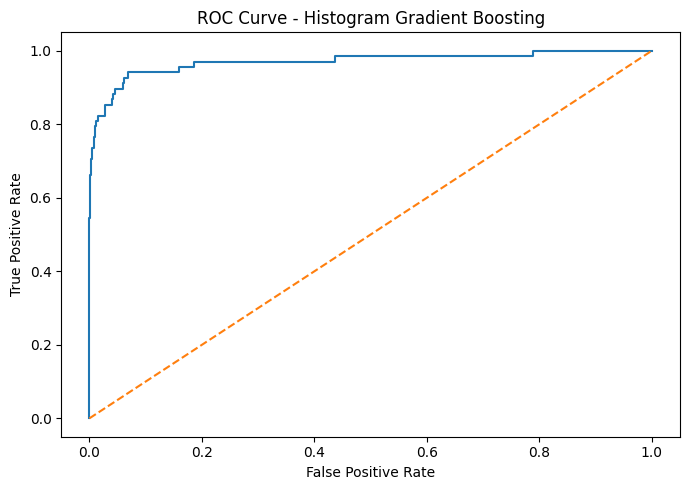

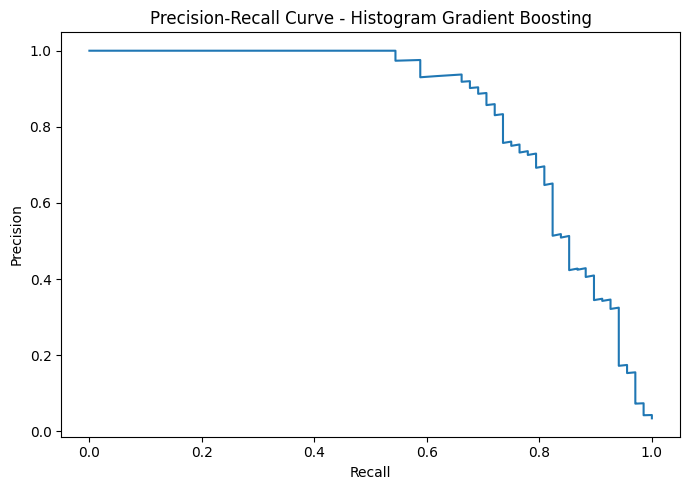

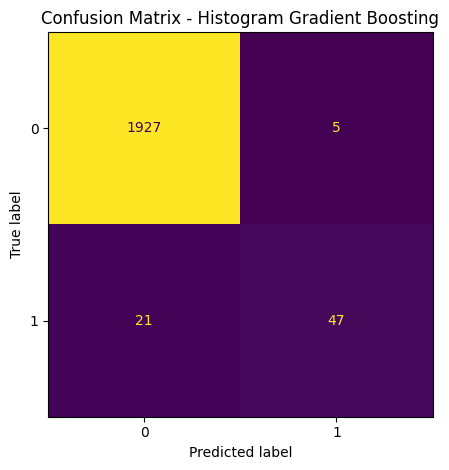

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.base import clone

all_probas = {}
all_preds = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", clone(model))
    ])

    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    all_probas[name] = proba
    all_preds[name] = pred


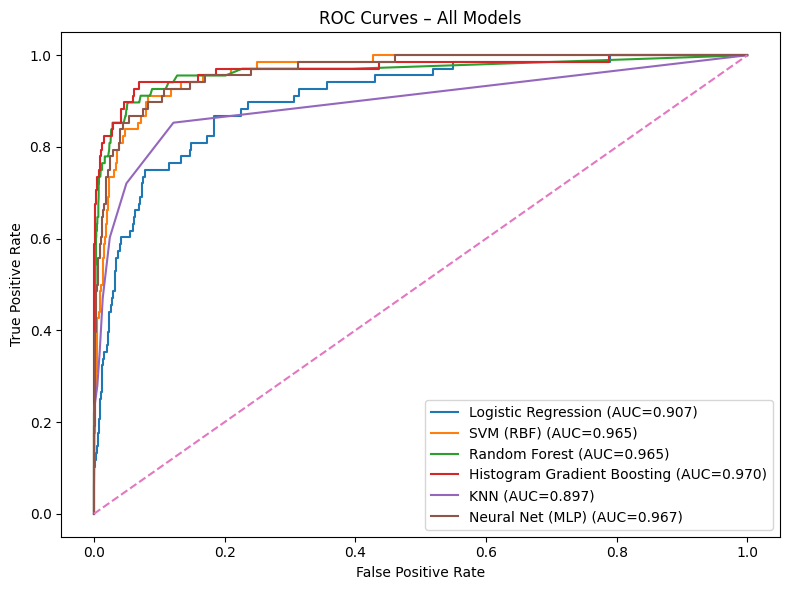

In [ ]:
plt.figure(figsize=(8,6))

for name, proba in all_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All Models")
plt.legend()
plt.tight_layout()
plt.show()


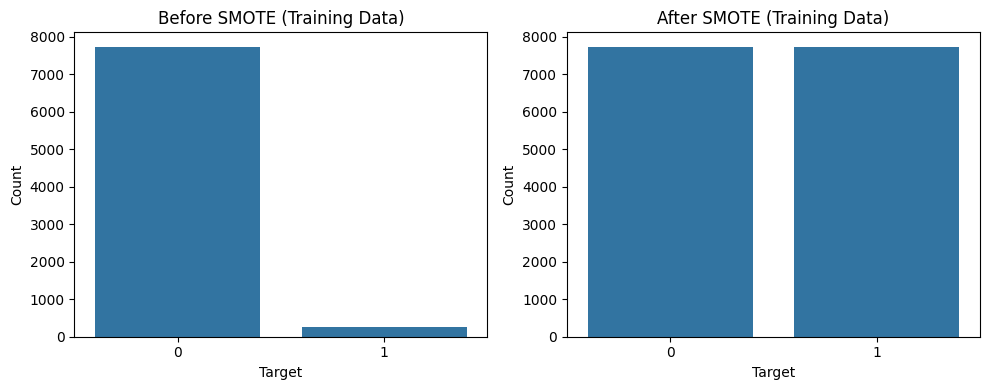

In [ ]:
from imblearn.over_sampling import SMOTE

X_train_processed = preprocess.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_processed, y_train)

# Plot before vs after SMOTE
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Before SMOTE (Training Data)")
plt.xlabel("Target")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(x=y_smote)
plt.title("After SMOTE (Training Data)")
plt.xlabel("Target")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


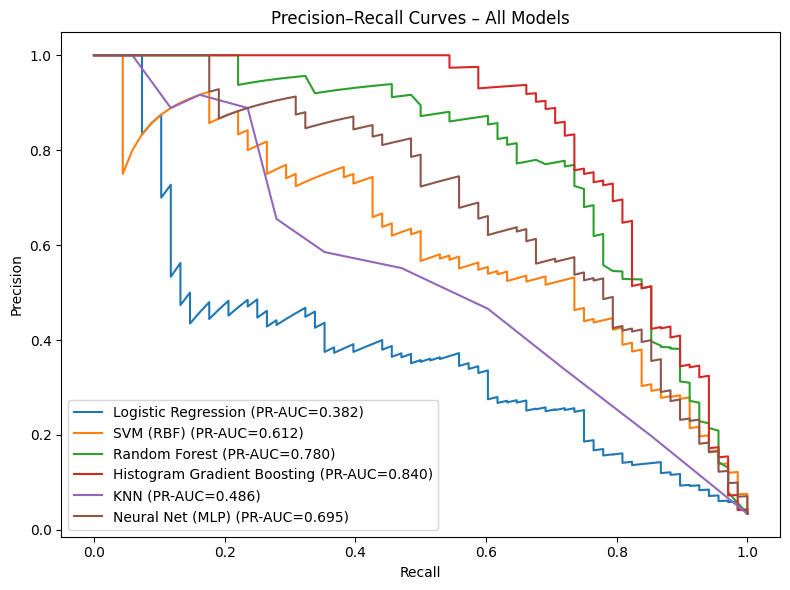

In [ ]:
plt.figure(figsize=(8,6))

for name, proba in all_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves – All Models")
plt.legend()
plt.tight_layout()
plt.show()


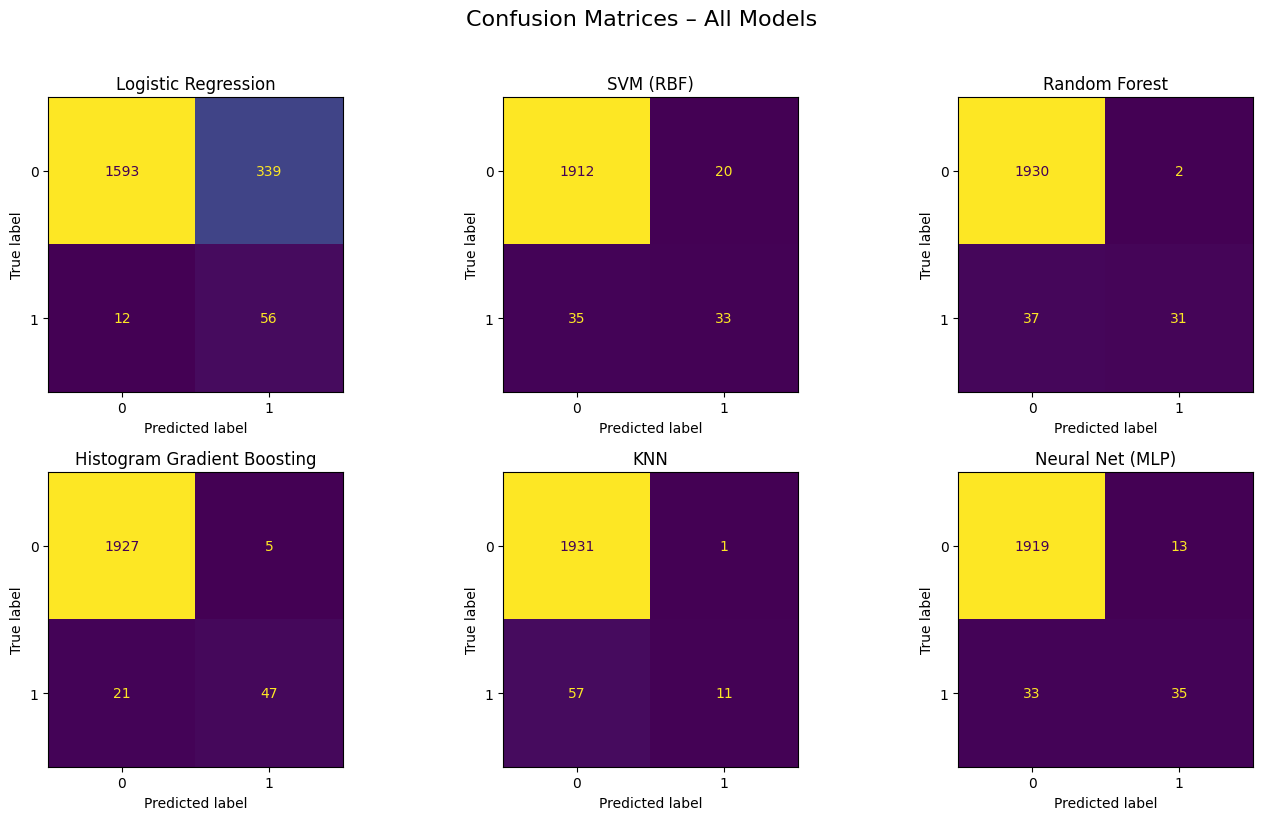

In [ ]:
import math

model_names = list(all_preds.keys())
n_models = len(model_names)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, all_preds[name])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

for i in range(len(model_names), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Confusion Matrices – All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
smote = SMOTE(random_state=42)

smote_models = {
    "Random Forest + SMOTE": RandomForestClassifier(
        n_estimators=500,
        random_state=42
    ),
    "Histogram Gradient Boosting + SMOTE": HistGradientBoostingClassifier(
        random_state=42
    ),
    "Neural Net (MLP) + SMOTE": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=250,
        early_stopping=True,
        random_state=42
    )
}


In [ ]:
smote_results = []

for name, model in smote_models.items():
    pipe = ImbPipeline([
        ("preprocess", preprocess),
        ("smote", smote),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    smote_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "Balanced Accuracy": scores["test_bal_acc"].mean()
    })

smote_results = pd.DataFrame(smote_results)
display(smote_results)


,Model,Accuracy,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Random Forest + SMOTE,0.970125,0.624656,0.963728,0.702892,0.856368
1,Histogram Gradient Boosting + SMOTE,0.971000,0.655839,0.973538,0.795120,0.894284
2,Neural Net (MLP) + SMOTE,0.948875,0.527827,0.955781,0.713937,0.891635


In [ ]:
comparison = pd.concat([
    cv_results.assign(Training="Without SMOTE"),
    smote_results.assign(Training="With SMOTE")
])

display(comparison.sort_values("PR-AUC", ascending=False))


,Model,Accuracy,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy,Training
3,Histogram Gradient Boosting,0.984250,0.733718,0.969915,0.811663,0.821224,Without SMOTE
1,Histogram Gradient Boosting + SMOTE,0.971000,0.655839,0.973538,0.795120,0.894284,With SMOTE
2,Random Forest,0.978125,0.547151,0.970322,0.751463,0.694976,Without SMOTE
2,Neural Net (MLP) + SMOTE,0.948875,0.527827,0.955781,0.713937,0.891635,With SMOTE
0,Random Forest + SMOTE,0.970125,0.624656,0.963728,0.702892,0.856368,With SMOTE
1,SVM (RBF),0.919125,0.421030,0.960223,0.660681,0.893975,Without SMOTE
5,Neural Net (MLP),0.971875,0.372790,0.929711,0.517457,0.625920,Without SMOTE
4,KNN,0.970000,0.248391,0.892507,0.516518,0.573324,Without SMOTE
0,Logistic Regression,0.822500,0.234570,0.896525,0.440897,0.813789,Without SMOTE


Week3